In [1]:
# ==========================================
# 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# ==========================================
# 2. LOAD DATASET
# ==========================================

df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding='latin1')

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

display(df.head())

DATASET LOADED SUCCESSFULLY
Rows    : 180,519
Columns : 53


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.25,314.64,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.11,0.04,180517,327.75,0.29,1,327.75,314.64,91.25,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.09,311.36,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.00,2,Fitness,18.28,-66.04,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.39,0.05,179254,327.75,-0.80,1,327.75,311.36,-249.09,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.78,309.72,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.00,2,Fitness,37.29,-121.88,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.03,0.06,179253,327.75,-0.80,1,327.75,309.72,-247.78,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.86,304.81,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.00,2,Fitness,34.13,-118.29,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.94,0.07,179252,327.75,0.08,1,327.75,304.81,22.86,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.21,298.25,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.00,2,Fitness,18.25,-66.04,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.50,0.09,179251,327.75,0.45,1,327.75,298.25,134.21,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
# ==========================================
# 3. DATASET OVERVIEW
# ==========================================

summary = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': round((df.isnull().sum()/len(df))*100,2),
    'Unique Values': df.nunique()
})

display(summary.sort_values('Missing %', ascending=False))

,Data Type,Missing Values,Missing %,Unique Values
Product Description,float64,180519,100.00,0
Order Zipcode,float64,155679,86.24,609
Days for shipment (scheduled),int64,0,0.00,4
Days for shipping (real),int64,0,0.00,7
Type,str,0,0.00,4
Delivery Status,str,0,0.00,4
Late_delivery_risk,int64,0,0.00,2
Category Id,int64,0,0.00,51
Category Name,str,0,0.00,50
Customer City,str,0,0.00,563


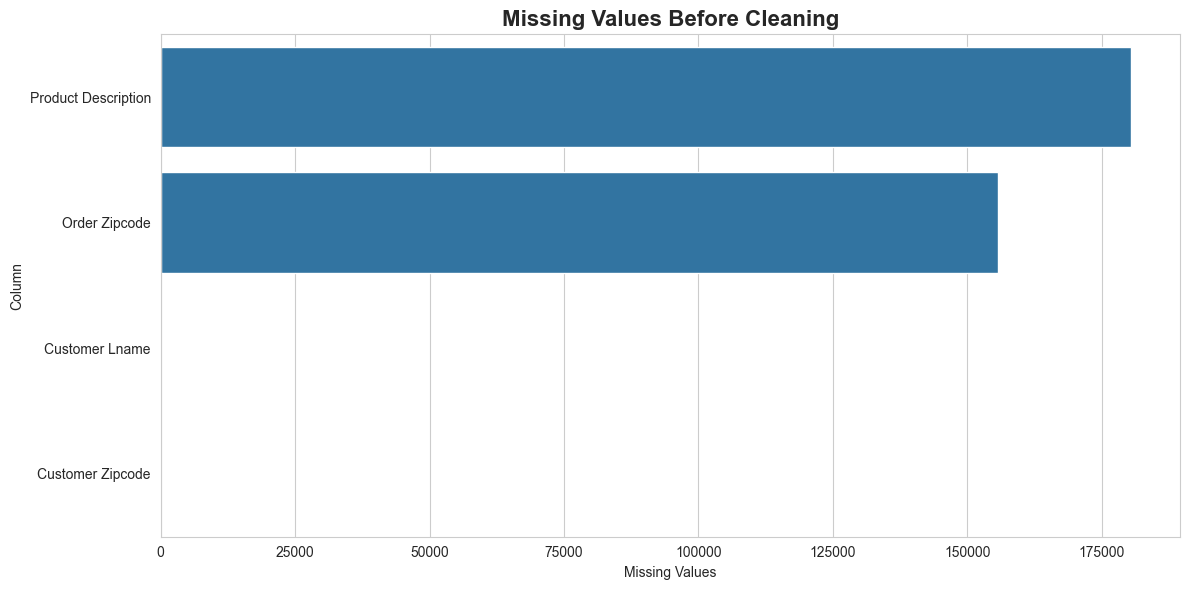

In [4]:
# ==========================================
# 4. VISUALIZING MISSING VALUES
# ==========================================

missing = pd.DataFrame({
    'Column': df.columns,
    'Missing Values': df.isnull().sum()
})

missing = missing[missing['Missing Values'] > 0]
missing = missing.sort_values(by='Missing Values', ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    data=missing,
    x='Missing Values',
    y='Column'
)

plt.title("Missing Values Before Cleaning",
          fontsize=16,
          weight='bold')

plt.tight_layout()
plt.show()

In [5]:
# ==========================================
# 5. DROP IRRELEVANT COLUMNS
# ==========================================

drop_columns = [

    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',

    'Product Description',
    'Product Image',

    'Order Zipcode'

]

df.drop(columns=drop_columns,
        inplace=True)

print(f"Remaining Columns: {df.shape[1]}")

Remaining Columns: 45


In [6]:
# ==========================================
# 6. HANDLE REMAINING MISSING VALUES
# ==========================================

df['Customer Zipcode'] = df['Customer Zipcode'].fillna(
    df['Customer Zipcode'].median()
)

print("Missing Values After Treatment")
print(df.isnull().sum().sum())

Missing Values After Treatment
0


In [7]:
# ==========================================
# 7. DUPLICATE CHECK
# ==========================================

duplicates = df.duplicated().sum()

print(f"Duplicate Rows Found: {duplicates}")

if duplicates > 0:
    df.drop_duplicates(inplace=True)

print(f"New Shape: {df.shape}")

Duplicate Rows Found: 0
New Shape: (180519, 45)


In [12]:
# ==========================================
# 8. DATE CONVERSION
# ==========================================

df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

In [13]:
# ==========================================
# 9. FEATURE ENGINEERING
# ==========================================

df['Order Year'] = df['order date (DateOrders)'].dt.year

df['Order Month'] = df['order date (DateOrders)'].dt.month

df['Order Day'] = df['order date (DateOrders)'].dt.day

df['Order Quarter'] = df['order date (DateOrders)'].dt.quarter

df['Shipping Delay'] = (
    df['Days for shipping (real)']
    -
    df['Days for shipment (scheduled)']
)

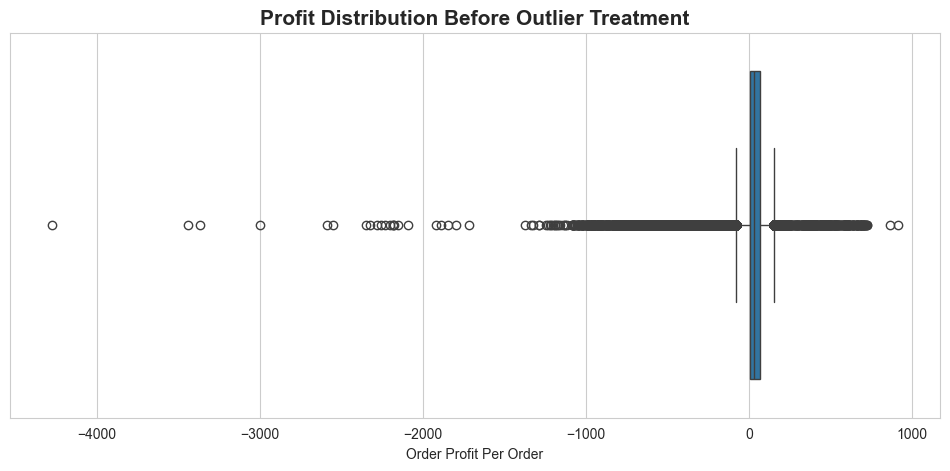

In [14]:
# ==========================================
# 10. OUTLIER ANALYSIS
# ==========================================

plt.figure(figsize=(12,5))

sns.boxplot(
    x=df['Order Profit Per Order']
)

plt.title(
    "Profit Distribution Before Outlier Treatment",
    fontsize=15,
    weight='bold'
)

plt.show()

In [15]:
# ==========================================
# 11. REMOVE EXTREME OUTLIERS
# ==========================================

Q1 = df['Order Profit Per Order'].quantile(0.25)

Q3 = df['Order Profit Per Order'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[
    (df['Order Profit Per Order'] >= lower)
    &
    (df['Order Profit Per Order'] <= upper)
]

print(df.shape)

(161577, 50)


In [16]:
# ==========================================
# 12. FINAL CLEANING SUMMARY
# ==========================================

report = pd.DataFrame({

    'Metric': [

        'Original Rows',
        'Original Columns',
        'Final Rows',
        'Final Columns',
        'Missing Values',
        'Duplicate Rows'

    ],

    'Value': [

        180519,
        53,
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()

    ]
})

display(report)

,Metric,Value
0,Original Rows,180519
1,Original Columns,53
2,Final Rows,161577
3,Final Columns,50
4,Missing Values,0
5,Duplicate Rows,0


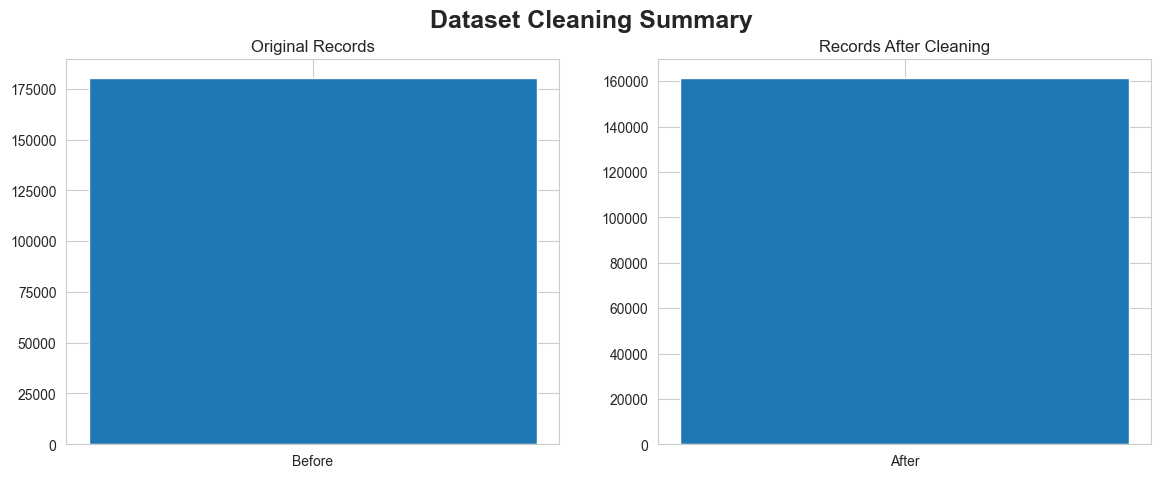

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(
    ["Before"],
    [180519],
)

ax[0].set_title("Original Records")

ax[1].bar(
    ["After"],
    [df.shape[0]],
)

ax[1].set_title("Records After Cleaning")

plt.suptitle("Dataset Cleaning Summary", fontsize=18, weight="bold")

plt.show()